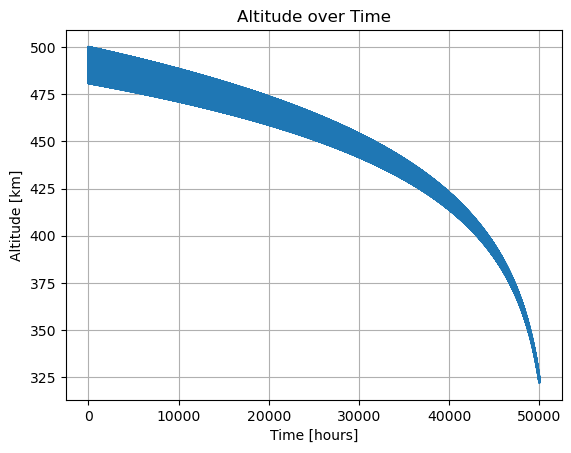

In [2]:
from datetime import datetime, timezone, timedelta
from orbit import simulation_config, propagate_orbit
import constants as const
from utils import conversions as conv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

def altitude_m(X):
    return np.linalg.norm(X[:3], axis=0) - const.EARTH_MU_m3_s2

# Setting up constants and initial conditions
propagation_method = "cowell"
mu = const.EARTH_MU_m3_s2
r0 = const.EARTH_RADIUS_EQ_m + 500000
v0 = math.sqrt(mu / r0)

x0 = np.array([
    r0, 0, 0,
    0, v0, 0
])

duration_hr = 50000
steps_per_hr = 30
t0 = datetime(2026, 9, 4, 0, 0, 0,tzinfo=timezone.utc)
tf = t0 + timedelta(hours=duration_hr)
config = simulation_config(
    t0=t0,
    tf=tf,
    time_steps=duration_hr*steps_per_hr,
    propagator_method=propagation_method,
    x0=x0,
    drag=True,
    J2=True
)

# running propagation
states = propagate_orbit(config)
alts = np.linalg.norm(states[:3], axis=0) - const.EARTH_RADIUS_EQ_m


times = np.linspace(0, duration_hr, duration_hr*steps_per_hr)


plt.plot(times, alts / 1000)

plt.xlabel("Time [hours]")
plt.ylabel("Altitude [km]")
plt.title("Altitude over Time")
plt.grid()
# plt.legend()
plt.show()